# Inception Model


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [3]:
import os

# Assuming balanced_dataset is defined as '/content/drive/MyDrive/balanced_dataset'
balanced_dataset_path = '/content/drive/MyDrive/balanced_dataset'

print(f"Contents of '{balanced_dataset_path}':")
if os.path.exists(balanced_dataset_path):
    for item in os.listdir(balanced_dataset_path):
        item_path = os.path.join(balanced_dataset_path, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: Directory '{balanced_dataset_path}' not found.")


Contents of '/content/drive/MyDrive/balanced_dataset':
  [DIR] balanced_dataset (contains 5 items)
  [DIR] amd (contains 1098 items)


In [4]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224, 224, 3)
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311
Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np

# -----------------------------------
# Image Data Generator
# -----------------------------------
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset",
    target_size=(299, 299),   # ⚠️ InceptionV3 expects 299x299
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# -----------------------------------
# Load InceptionV3
# -----------------------------------
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling
    input_shape=(299, 299, 3)
)

# -----------------------------------
# Feature Extraction
# -----------------------------------
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)

print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 1655s 10s/step
Features shape: (5311, 2048)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)


Train shape: (4248, 2048) Val shape: (1063, 2048)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.6005 - loss: 1.0907 - val_accuracy: 0.7658 - val_loss: 0.7336 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.7413 - loss: 0.6872 - val_accuracy: 0.8241 - val_loss: 0.4793 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.7780 - loss: 0.5982 - val_accuracy: 0.8579 - val_loss: 0.3947 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8070 - loss: 0.5180 - val_accuracy: 0.8674 - val_loss: 0.3702 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8218 - loss: 0.4652 - val_accuracy: 0.8730 - val_loss: 0.3396 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8338 - loss: 0.4421 - val_accuracy: 0.8796 - val_loss: 0.3175 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - 

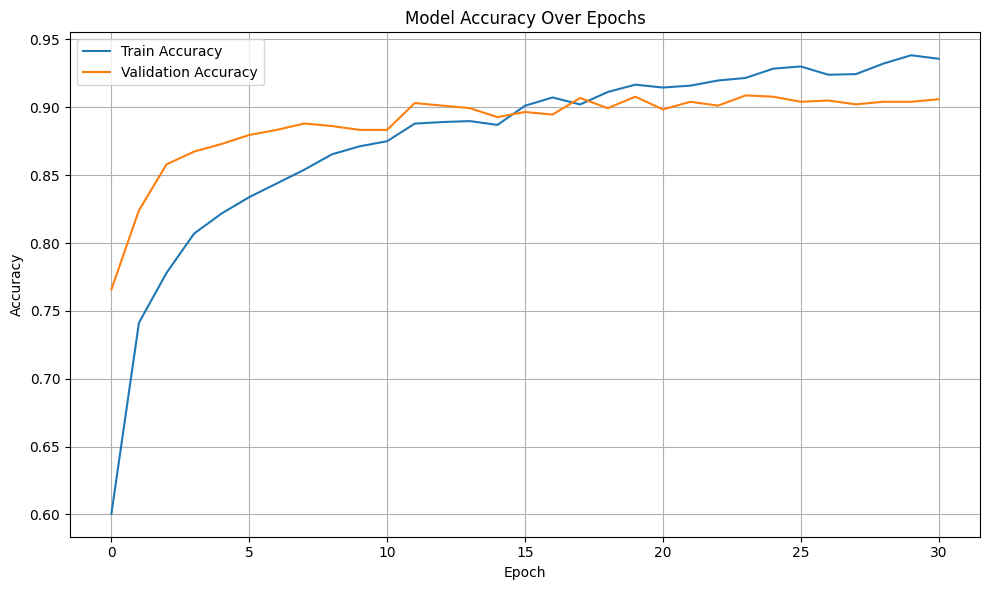

Final Training Accuracy: 0.9357
Final Validation Accuracy: 0.9059


In [12]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [9]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .h5 file
model.save("eye_disease_classifier_inception.h5")
print("Model saved as eye_disease_classifier_inception.h5")

Model saved as eye_disease_classifier_inception.h5


# MobileNet Model


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [16]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311
Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


In [17]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224, 224, 3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# --------------------------------------------------
# Image Generator (MobileNetV2 preprocessing)
# --------------------------------------------------
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# --------------------------------------------------
# Load MobileNetV2
# --------------------------------------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# --------------------------------------------------
# Feature Extraction
# --------------------------------------------------
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)

print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step
Features shape: (5311, 1280)


In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (4248, 1280) Val shape: (1063, 1280)


In [20]:
model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.6),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [22]:
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)



In [23]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.4673 - loss: 1.7805 - val_accuracy: 0.7817 - val_loss: 0.6271 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6589 - loss: 1.0395 - val_accuracy: 0.8147 - val_loss: 0.4779 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7234 - loss: 0.8451 - val_accuracy: 0.8467 - val_loss: 0.4174 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.7524 - loss: 0.7507 - val_accuracy: 0.8495 - val_loss: 0.4009 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7622 - loss: 0.6836 - val_accuracy: 0.8627 - val_loss: 0.3744 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7903 - loss: 0.6214 - val_accuracy: 0.8702 - val_loss: 0.3515 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - ac

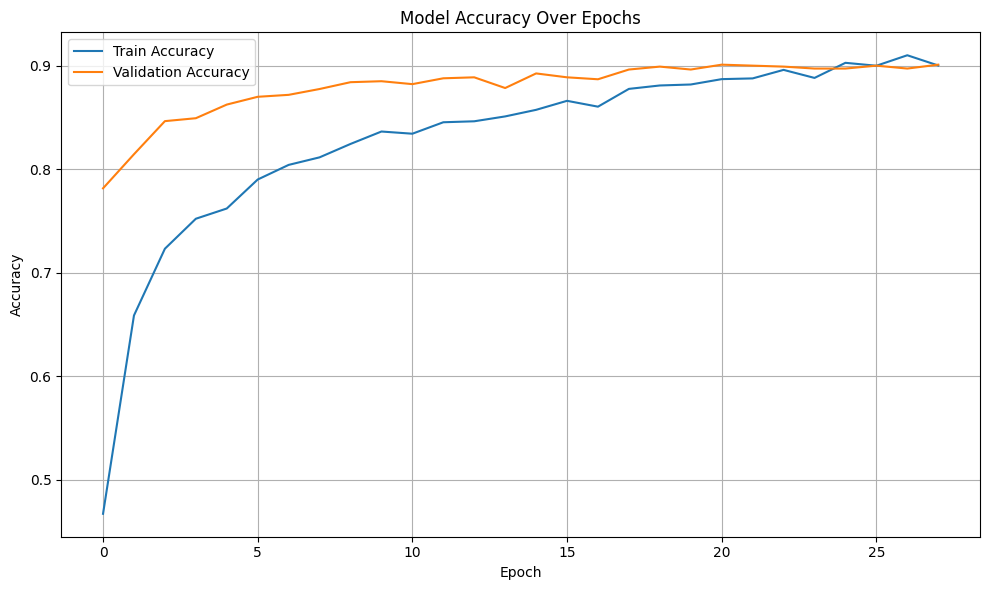

Final Training Accuracy: 0.9004
Final Validation Accuracy: 0.9012


In [24]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [25]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .h5 file
model.save("eye_disease_classifier_mobilenetv2.h5")
print("Model saved as eye_disease_classifier_mobilenetv2.h5")

Model saved as eye_disease_classifier_mobilenetv2.h5


In [ ]:
from google.colab import files
files.download("eye_disease_classifier_mobilenetv2.h5")


# MobileNetV2 Model


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [28]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311
Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


In [29]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224, 224, 3)
)


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# --------------------------------------------------
# Image Generator (MobileNetV2 preprocessing)
# --------------------------------------------------
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# --------------------------------------------------
# Load MobileNetV2
# --------------------------------------------------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

# --------------------------------------------------
# Feature Extraction
# --------------------------------------------------
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)

print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step
Features shape: (5311, 1280)


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (4248, 1280) Val shape: (1063, 1280)


In [32]:
model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [34]:
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)



In [35]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5819 - loss: 1.1549 - val_accuracy: 0.8250 - val_loss: 0.5708 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7540 - loss: 0.6869 - val_accuracy: 0.8467 - val_loss: 0.4159 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8023 - loss: 0.5644 - val_accuracy: 0.8664 - val_loss: 0.3621 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8152 - loss: 0.5075 - val_accuracy: 0.8730 - val_loss: 0.3434 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8392 - loss: 0.4391 - val_accuracy: 0.8721 - val_loss: 0.3182 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8559 - loss: 0.3937 - val_accuracy: 0.8805 - val_loss: 0.3159 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - acc

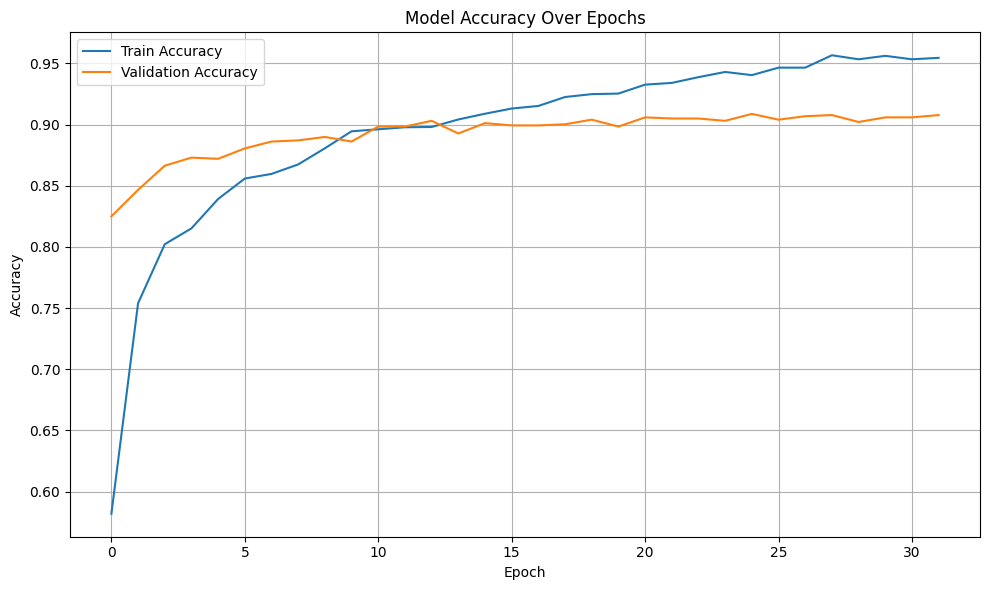

Final Training Accuracy: 0.9546
Final Validation Accuracy: 0.9078


In [36]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [7]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .h5 file
model.save("eye_disease_classifier_mobilenetv2.h5")
print("Model saved as eye_disease_classifier_mobilenetv2.h5")

Model saved as eye_disease_classifier_mobilenetv2.h5


In [ ]:
from google.colab import files
files.download("eye_disease_classifier_mobilenetv2.h5")


# ResNet Model


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [40]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311
Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


In [41]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224, 224, 3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
import numpy as np

# -----------------------------------
# Image Data Generator
# -----------------------------------
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# -----------------------------------
# Load ResNet
# -----------------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling
    input_shape=(224, 224, 3)
)

# -----------------------------------
# Feature Extraction
# -----------------------------------
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)

print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 1001s 6s/step
Features shape: (5311, 2048)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (4248, 2048) Val shape: (1063, 2048)


In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [57]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)

In [58]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.6387 - loss: 1.0407 - val_accuracy: 0.8476 - val_loss: 0.4650 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.7893 - loss: 0.5599 - val_accuracy: 0.8739 - val_loss: 0.3410 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.8310 - loss: 0.4513 - val_accuracy: 0.8758 - val_loss: 0.3082 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8517 - loss: 0.4040 - val_accuracy: 0.8881 - val_loss: 0.2840 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.8630 - loss: 0.3659 - val_accuracy: 0.8928 - val_loss: 0.2674 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8710 - loss: 0.3417 - val_accuracy: 0.9078 - val_loss: 0.2362 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - 

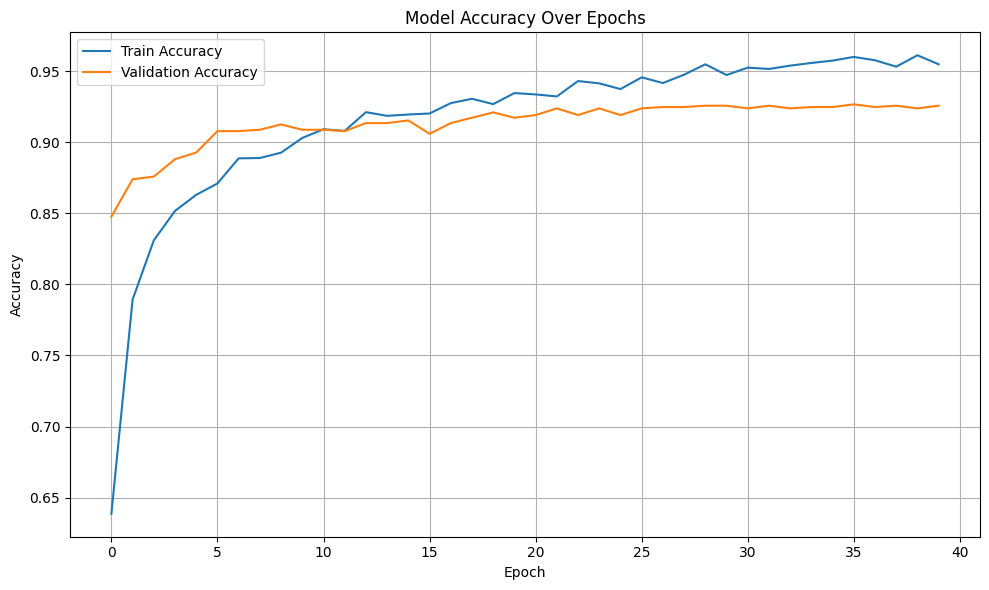

Final Training Accuracy: 0.9548
Final Validation Accuracy: 0.9257


In [59]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [61]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .h5 file
model.save("eye_disease_classifier_Resnet50.h5")
print("Model saved as eye_disease_classifier_Resnet50.h5")

Model saved as eye_disease_classifier_Resnet50.h5


In [ ]:
from google.colab import files
files.download("eye_disease_classifier_Resnet50.h5")

# VGG16 Model


In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [64]:
dataset_dir = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"  # change path

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False  # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))


Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311


In [65]:
import numpy as np

# Count images per class
class_counts = np.bincount(labels)

# Print nicely
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


In [66]:
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

original_dataset = "/content/drive/MyDrive/dataset"
balanced_dataset = "/content/drive/MyDrive/balanced_dataset"

os.makedirs(balanced_dataset, exist_ok=True)

# Target = max class count
target_count = max(class_counts)
print("Target images per class:", target_count)


Target images per class: 1098


In [67]:
print("\nBalanced dataset distribution:")
for cls in sorted(os.listdir(balanced_dataset)):
    cls_path = os.path.join(balanced_dataset, cls)
    print(f"Class '{cls}': {len(os.listdir(cls_path))} images")



Balanced dataset distribution:
Class 'amd': 1098 images
Class 'balanced_dataset': 5 images


In [68]:
base_model = VGG16(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))

# Extract features (fast, done only once)
X = base_model.predict(generator, verbose=1)
print("Features shape:", X.shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 3019s 18s/step
Features shape: (5311, 512)


In [69]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 6409 images belonging to 2 classes.
Classes: ['amd', 'balanced_dataset']
Total images: 6409
Class 'amd': 1098 images
Class 'balanced_dataset': 5311 images


In [70]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224,224,3)
)


In [71]:
from PIL import Image
import os

for cls in os.listdir(balanced_dataset):
    cls_path = os.path.join(balanced_dataset, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            Image.open(img_path).verify()  # verifies if image is okay
        except (IOError, SyntaxError) as e:
            print(f"Corrupted image: {img_path}")


Corrupted image: /content/drive/MyDrive/balanced_dataset/balanced_dataset/cataract
Corrupted image: /content/drive/MyDrive/balanced_dataset/balanced_dataset/normal
Corrupted image: /content/drive/MyDrive/balanced_dataset/balanced_dataset/glaucoma
Corrupted image: /content/drive/MyDrive/balanced_dataset/balanced_dataset/diabetic_retinopathy
Corrupted image: /content/drive/MyDrive/balanced_dataset/balanced_dataset/amd
Corrupted image: /content/drive/MyDrive/balanced_dataset/amd/1879_left.jpg


In [72]:
import os

corrupted_images = [
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset/glaucoma/1020_left.jpg",
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset/cataract/1062_right.jpg"
]

for img_path in corrupted_images:
    if os.path.exists(img_path):
        os.remove(img_path)
        print(f"Deleted: {img_path}")


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset", # Corrected path
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# Load VGG16
base_model = VGG16(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))

# Feature extraction
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)
print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 3062s 18s/step
Features shape: (5311, 512)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (4248, 512) Val shape: (1063, 512)


In [6]:
model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [8]:
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)



In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5435 - loss: 1.2904 - val_accuracy: 0.7761 - val_loss: 0.5794 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7222 - loss: 0.7492 - val_accuracy: 0.8504 - val_loss: 0.4023 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7669 - loss: 0.6124 - val_accuracy: 0.8598 - val_loss: 0.3576 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7985 - loss: 0.5429 - val_accuracy: 0.8598 - val_loss: 0.3240 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8216 - loss: 0.4698 - val_accuracy: 0.8777 - val_loss: 0.2924 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8317 - loss: 0.4545 - val_accuracy: 0.8909 - val_loss: 0.2737 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc

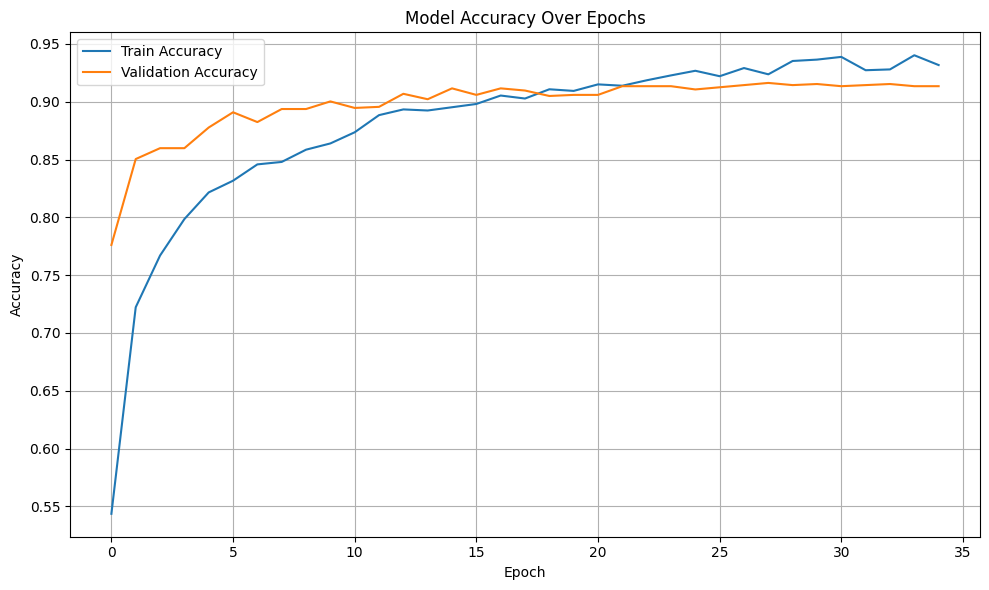

Final Training Accuracy: 0.9317
Final Validation Accuracy: 0.9135


In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [37]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .keras file
model.save("eye_disease_classifier_vgg16.keras")
print("Model saved as eye_disease_classifier_vgg16.keras")

Model saved as eye_disease_classifier_vgg16.keras


In [38]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16

# Load base model again (you don’t need to save it)
base_model = VGG16(weights="imagenet", include_top=False, pooling="avg", input_shape=(224, 224, 3))

# Load your trained classifier
model = load_model("eye_disease_classifier_vgg16.h5")
print("Model loaded successfully.")


Model loaded successfully.


# DenseNet121 Model


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [15]:
# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")


Found 6409 images belonging to 2 classes.
Classes: ['amd', 'balanced_dataset']
Total images: 6409
Class 'amd': 1098 images
Class 'balanced_dataset': 5311 images


In [16]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling for flat features
    input_shape=(224, 224, 3)
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
import numpy as np

# -----------------------------------
# Image Data Generator
# -----------------------------------
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/balanced_dataset/balanced_dataset", # Corrected path
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels = generator.classes
class_names = list(generator.class_indices.keys())

from tensorflow.keras.utils import to_categorical
y = to_categorical(labels, num_classes=len(class_names))

# -----------------------------------
# Load DenseNet
# -----------------------------------
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    pooling="avg",        # GlobalAveragePooling
    input_shape=(224, 224, 3)
)

# -----------------------------------
# Feature Extraction
# -----------------------------------
steps = int(np.ceil(generator.samples / generator.batch_size))
X = base_model.predict(generator, steps=steps, verbose=1)

print("Features shape:", X.shape)


Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 1067s 6s/step
Features shape: (5311, 1024)


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (4248, 1024) Val shape: (1063, 1024)


In [21]:
model = Sequential([
    Dense(1024, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(y_train.shape[1], activation="softmax")  # number of classes
])



In [25]:
opt = Adam(learning_rate=1e-4)  # small LR for stable training
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [26]:
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)

In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6015 - loss: 1.0811 - val_accuracy: 0.8147 - val_loss: 0.5450 - learning_rate: 1.0000e-04
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7674 - loss: 0.6556 - val_accuracy: 0.8683 - val_loss: 0.3624 - learning_rate: 1.0000e-04
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8046 - loss: 0.5391 - val_accuracy: 0.8796 - val_loss: 0.3216 - learning_rate: 1.0000e-04
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8340 - loss: 0.4605 - val_accuracy: 0.8833 - val_loss: 0.2859 - learning_rate: 1.0000e-04
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.8366 - loss: 0.4361 - val_accuracy: 0.8918 - val_loss: 0.2734 - learning_rate: 1.0000e-04
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8635 - loss: 0.3825 - val_accuracy: 0.8965 - val_loss: 0.2497 - learning_rate: 1.0000e-04
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - acc

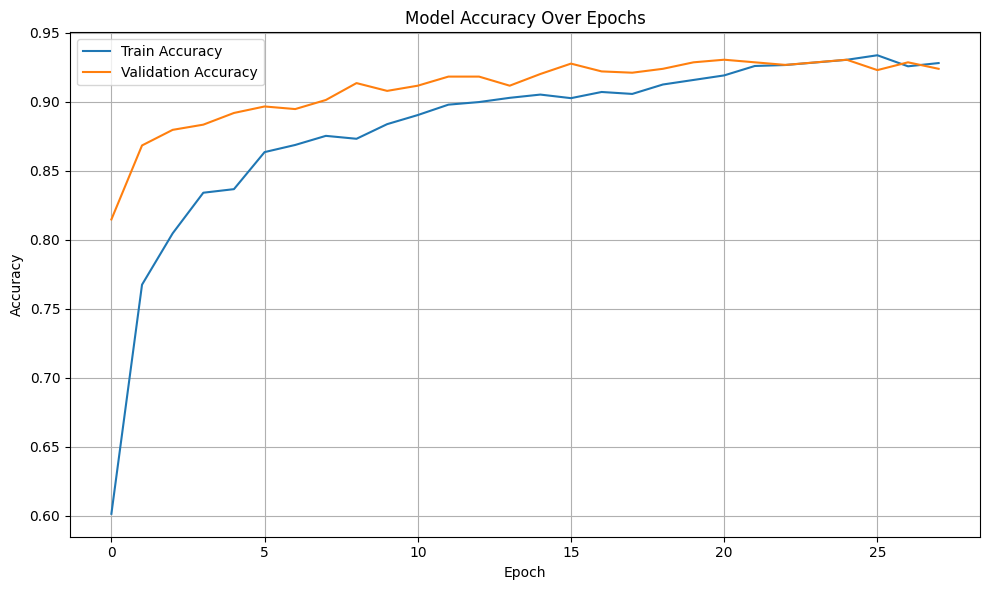

Final Training Accuracy: 0.9280
Final Validation Accuracy: 0.9238


In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final accuracy values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


In [29]:
from tensorflow.keras.models import save_model

# Save the trained classifier to .h5 file
model.save("eye_disease_classifier_Densenet121.h5")
print("Model saved as eye_disease_classifier_Densenet121.h5")

Model saved as eye_disease_classifier_Densenet121.h5


In [30]:
from google.colab import files
files.download("eye_disease_classifier_Densenet121.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Ensemble Voting and Model Saving
Code to combine all trained models and save them for future prediction.


In [10]:
# Load saved models for ensemble prediction
from tensorflow.keras.models import load_model

model_vgg = load_model('eye_disease_classifier_vgg16.keras')
model_resnet = load_model('eye_disease_classifier_Resnet50.h5')
model_mob = load_model('eye_disease_classifier_mobilenetv2.h5')
model_dense = load_model('eye_disease_classifier_Densenet121.h5')
model_inception = load_model('eye_disease_classifier_inception.h5')

print('Models loaded successfully')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Models loaded successfully


In [41]:
# Soft Voting Ensemble Prediction
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, DenseNet121, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define the balanced dataset path
balanced_dataset_path = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

# --- Create a common generator for the full dataset (to get consistent splits) ---
# Using VGG16's preprocessing for initial label extraction, but target_size is flexible
# for this initial step as we'll re-generate specific features later.
# Make sure this generator has shuffle=False to maintain order for splitting
initial_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg)
initial_generator = initial_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(224, 224), # Arbitrary size for label extraction
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

labels_full_dataset = initial_generator.classes
class_names = list(initial_generator.class_indices.keys())
y_full_dataset = to_categorical(labels_full_dataset, num_classes=len(class_names))

# --- Now, extract features for X_val for EACH model ---
# This ensures that each model gets features extracted by its corresponding base model.

# 1. VGG16 Features
print("Extracting VGG16 features...")
vgg_base_model = VGG16(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
vgg_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg)
vgg_generator = vgg_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
steps_vgg = int(np.ceil(vgg_generator.samples / vgg_generator.batch_size))
X_vgg = vgg_base_model.predict(vgg_generator, steps=steps_vgg, verbose=1)
_, X_val_vgg, _, _ = train_test_split(X_vgg, y_full_dataset, test_size=0.2, random_state=42, stratify=y_full_dataset)

# 2. ResNet50 Features
print("\nExtracting ResNet50 features...")
resnet_base_model = ResNet50(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
resnet_datagen = ImageDataGenerator(preprocessing_function=preprocess_resnet)
resnet_generator = resnet_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
steps_resnet = int(np.ceil(resnet_generator.samples / resnet_generator.batch_size))
X_resnet = resnet_base_model.predict(resnet_generator, steps=steps_resnet, verbose=1)
_, X_val_resnet, _, _ = train_test_split(X_resnet, y_full_dataset, test_size=0.2, random_state=42, stratify=y_full_dataset)

# 3. MobileNetV2 Features
print("\nExtracting MobileNetV2 features...")
mobilenet_base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
mobilenet_datagen = ImageDataGenerator(preprocessing_function=preprocess_mobilenet)
mobilenet_generator = mobilenet_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
steps_mobilenet = int(np.ceil(mobilenet_generator.samples / mobilenet_generator.batch_size))
X_mobilenet = mobilenet_base_model.predict(mobilenet_generator, steps=steps_mobilenet, verbose=1)
_, X_val_mobilenet, _, _ = train_test_split(X_mobilenet, y_full_dataset, test_size=0.2, random_state=42, stratify=y_full_dataset)

# 4. DenseNet121 Features
print("\nExtracting DenseNet121 features...")
densenet_base_model = DenseNet121(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
densenet_datagen = ImageDataGenerator(preprocessing_function=preprocess_densenet)
densenet_generator = densenet_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
steps_densenet = int(np.ceil(densenet_generator.samples / densenet_generator.batch_size))
X_densenet = densenet_base_model.predict(densenet_generator, steps=steps_densenet, verbose=1)
_, X_val_densenet, _, _ = train_test_split(X_densenet, y_full_dataset, test_size=0.2, random_state=42, stratify=y_full_dataset)

# 5. InceptionV3 Features (Note: InceptionV3 uses 299x299 input size)
print("\nExtracting InceptionV3 features...")
inception_base_model = InceptionV3(weights="imagenet", include_top=False, pooling="avg", input_shape=(299,299,3))
inception_datagen = ImageDataGenerator(preprocessing_function=preprocess_inception)
inception_generator = inception_datagen.flow_from_directory(
    balanced_dataset_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
steps_inception = int(np.ceil(inception_generator.samples / inception_generator.batch_size))
X_inception = inception_base_model.predict(inception_generator, steps=steps_inception, verbose=1)
_, X_val_inception, _, _ = train_test_split(X_inception, y_full_dataset, test_size=0.2, random_state=42, stratify=y_full_dataset)


# --- Perform predictions with correct feature sets ---
print("\nPerforming ensemble predictions...")
pred1 = model_vgg.predict(X_val_vgg)
pred2 = model_resnet.predict(X_val_resnet)
pred3 = model_mob.predict(X_val_mobilenet)
pred4 = model_dense.predict(X_val_densenet)
pred5 = model_inception.predict(X_val_inception)

ensemble_pred = (pred1 + pred2 + pred3 + pred4 + pred5) / 5

final_predictions = np.argmax(ensemble_pred, axis=1)
print('Ensemble prediction completed')


Found 5311 images belonging to 5 classes.
Extracting VGG16 features...
Found 5311 images belonging to 5 classes.


166/166 ━━━━━━━━━━━━━━━━━━━━ 3057s 18s/step

Extracting ResNet50 features...
Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 982s 6s/step

Extracting MobileNetV2 features...
Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step

Extracting DenseNet121 features...
Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 1010s 6s/step

Extracting InceptionV3 features...
Found 5311 images belonging to 5 classes.
166/166 ━━━━━━━━━━━━━━━━━━━━ 1326s 8s/step

Performing ensemble predictions...
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Ensemble prediction completed


Ensemble Model Accuracy: 0.9464

Ensemble Model Classification Report:
                      precision    recall  f1-score   support

                 amd       1.00      1.00      1.00       220
            cataract       0.94      0.98      0.96       207
diabetic_retinopathy       1.00      0.99      0.99       220
            glaucoma       0.89      0.85      0.87       201
              normal       0.90      0.92      0.91       215

            accuracy                           0.95      1063
           macro avg       0.95      0.94      0.94      1063
        weighted avg       0.95      0.95      0.95      1063



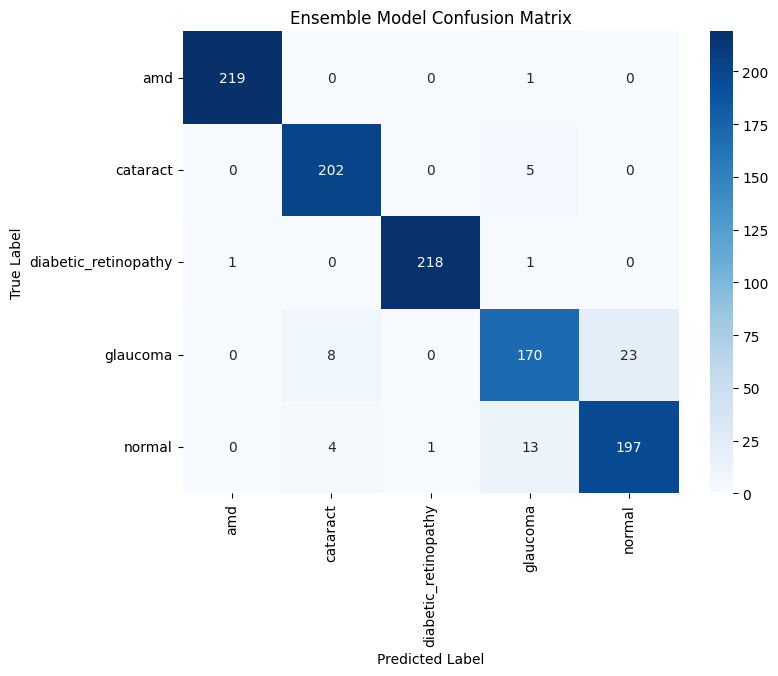

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert one-hot encoded y_val to single class labels
y_val_labels = np.argmax(y_val, axis=1)

# Calculate accuracy
ensemble_accuracy = accuracy_score(y_val_labels, final_predictions)
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")

# Generate classification report
print("\nEnsemble Model Classification Report:")
print(classification_report(y_val_labels, final_predictions, target_names=class_names))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_val_labels, final_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Ensemble Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.utils import to_categorical

# Use balanced dataset
balanced_dataset = "/content/drive/MyDrive/balanced_dataset/balanced_dataset"

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    balanced_dataset,          # <-- point here
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False              # important for correct label order
)

labels = generator.classes
class_names = list(generator.class_indices.keys())
y = to_categorical(labels, num_classes=len(class_names))

print("Classes:", class_names)
print("Total images:", len(labels))

# Count images per class
class_counts = np.bincount(labels)
for i, count in enumerate(class_counts):
    print(f"Class '{class_names[i]}': {count} images")

Found 5311 images belonging to 5 classes.
Classes: ['amd', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Total images: 5311
Class 'amd': 1098 images
Class 'cataract': 1036 images
Class 'diabetic_retinopathy': 1098 images
Class 'glaucoma': 1005 images
Class 'normal': 1074 images


## Gradio Interface for VGG16 Model

This section demonstrates how to create an interactive web interface using Gradio to test the VGG16 model. You can upload an eye image, and the model will predict the disease category.

In [31]:
# Install Gradio if not already installed
!pip install gradio -qq

In [12]:
model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,423,244 (13.06 MB)

 Trainable params: 1,710,085 (6.52 MB)

 Non-trainable params: 3,072 (12.00 KB)

 Optimizer params: 1,710,087 (6.52 MB)

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import DenseNet121, ResNet50, MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from PIL import Image

# -----------------------------
# Load models
# -----------------------------
model_vgg = load_model("eye_disease_classifier_vgg16.keras")      # 1024
model_resnet = load_model("eye_disease_classifier_Resnet50.h5")   # 2048
model_mob = load_model("/content/eye_disease_classifier_mobilenetv2 (1).h5")   # 1280
model_dense = load_model("eye_disease_classifier_Densenet121.h5") # 1024
model_inception = load_model("eye_disease_classifier_inception.h5") # 1024 (FIXED)

# -----------------------------
# Base models
# -----------------------------
densenet_base = DenseNet121(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
resnet_base = ResNet50(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))

class_names = ["amd", "cataract", "diabetic_retinopathy", "glaucoma", "normal"]

# -----------------------------
# Prediction
# -----------------------------
def predict_ensemble(img):
    img = img.convert("RGB")
    img_224 = img.resize((224, 224))
    arr = np.expand_dims(np.array(img_224), axis=0)

    # -------- DenseNet features (1024) --------
    arr_den = preprocess_densenet(arr.copy())
    feat_den = densenet_base.predict(arr_den)

    pred1 = model_vgg.predict(feat_den)
    pred4 = model_dense.predict(feat_den)
    pred5 = model_inception.predict(feat_den)   # FIXED

    # -------- ResNet (2048) --------
    arr_res = preprocess_resnet(arr.copy())
    feat_res = resnet_base.predict(arr_res)
    pred2 = model_resnet.predict(feat_res)

    # -------- MobileNet (1280) --------
    arr_mob = preprocess_mobilenet(arr.copy())
    feat_mob = mobilenet_base.predict(arr_mob)
    pred3 = model_mob.predict(feat_mob)

    # -------- Ensemble --------
    ensemble_pred = (pred1 + pred2 + pred3 + pred4 + pred5) / 5

    probs = ensemble_pred[0]
    return {
        class_names[i]: float(probs[i])
        for i in np.argsort(probs)[::-1]
    }

# -----------------------------
# Gradio UI
# -----------------------------
demo = gr.Interface(
    fn=predict_ensemble,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=5),
    title="Eye Disease Detection (Ensemble Model)"
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://05adf88d1f5e86b299.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
